In [5]:
# Core Data Manipulation
import pandas as pd
import numpy as np

# Business Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Superstore dataset using the correct Windows encoding
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

print("Data loaded successfully! Here is a preview:")
# Display the first 5 rows
display(df.head())

Data loaded successfully! Here is a preview:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# 1. Check for any missing data (Null values)
print("--- Missing Values in Each Column ---")
print(df.isnull().sum())
print("\n" + "="*35 + "\n")

# 2. Convert 'Order Date' from text to actual Date/Time format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 3. Sort the data from oldest to newest (Crucial for Time-Series forecasting!)
df = df.sort_values('Order Date')

print("--- Data Types After Conversion ---")
# Let's check if Order Date is now a 'datetime' object
print(df[['Order Date', 'Sales', 'Profit']].dtypes)

--- Missing Values in Each Column ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


--- Data Types After Conversion ---
Order Date    datetime64[us]
Sales                float64
Profit               float64
dtype: object


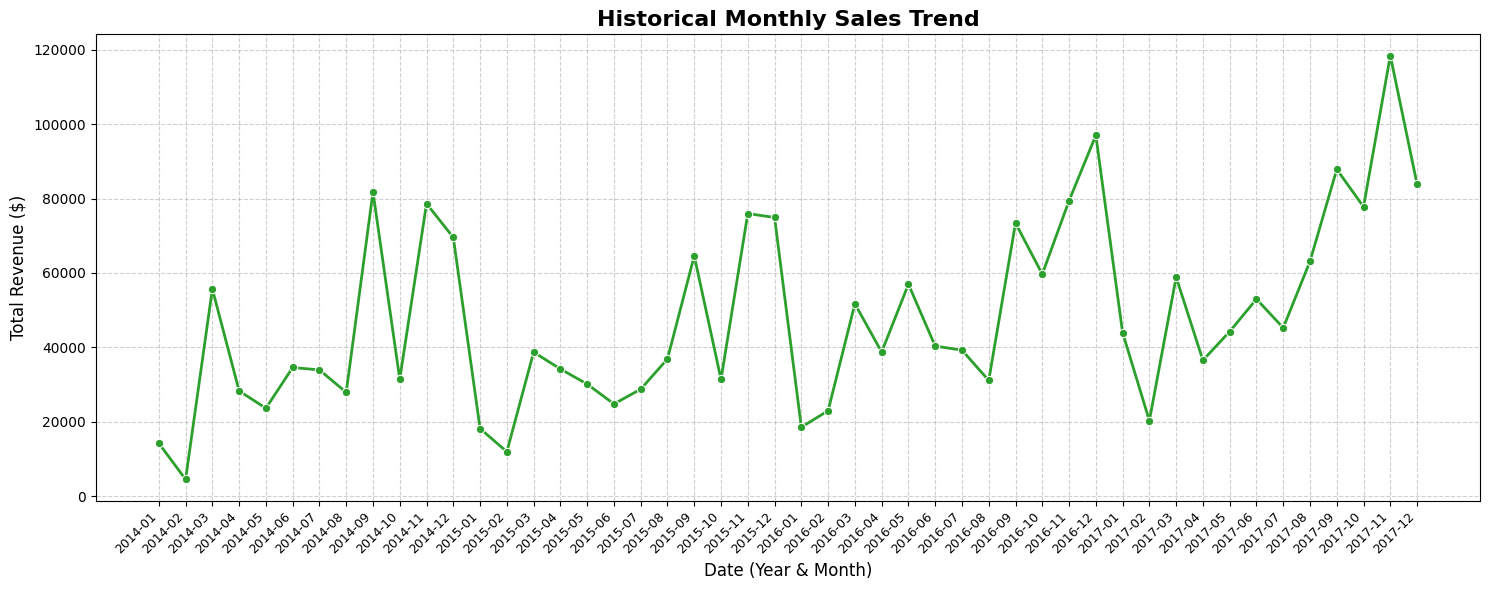

In [7]:
# 1. Create time-based features (Crucial for our ML model later!)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Create a clean 'Year-Month' column for our charts (e.g., '2014-01')
df['Year-Month'] = df['Order Date'].dt.to_period('M')

# 2. Group the data to calculate the TOTAL sales for every single month
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str) # Format for plotting

# 3. Build a Professional Business Visualization
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='Year-Month', y='Sales', marker='o', color='#2ca02c', linewidth=2)

# Make it look like a real business dashboard
plt.title('Historical Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Date (Year & Month)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Rotate the dates on the bottom so they don't overlap
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the chart!
plt.show()

In [9]:
# --- THE FIX: Import the Machine Learning Tools ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. Create a numerical 'Time Index' (1, 2, 3...) for the ML model
monthly_sales['Time_Index'] = np.arange(1, len(monthly_sales) + 1)

# 2. Define our Input Feature (X) and Target to Predict (y)
X = monthly_sales[['Time_Index']]  # Time is our input
y = monthly_sales['Sales']         # Sales is what we want to predict

# 3. Split the data: Train on the older data, Test on the most recent 20%
# We set shuffle=False because chronological order matters in time-series!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Initialize and Train the Machine Learning Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions on the test set
predictions = model.predict(X_test)

# 6. Evaluate the Model (How far off were we on average?)
mae = mean_absolute_error(y_test, predictions)

print("✅ Model Training Complete!")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")

✅ Model Training Complete!
Mean Absolute Error (MAE): $18,041.64


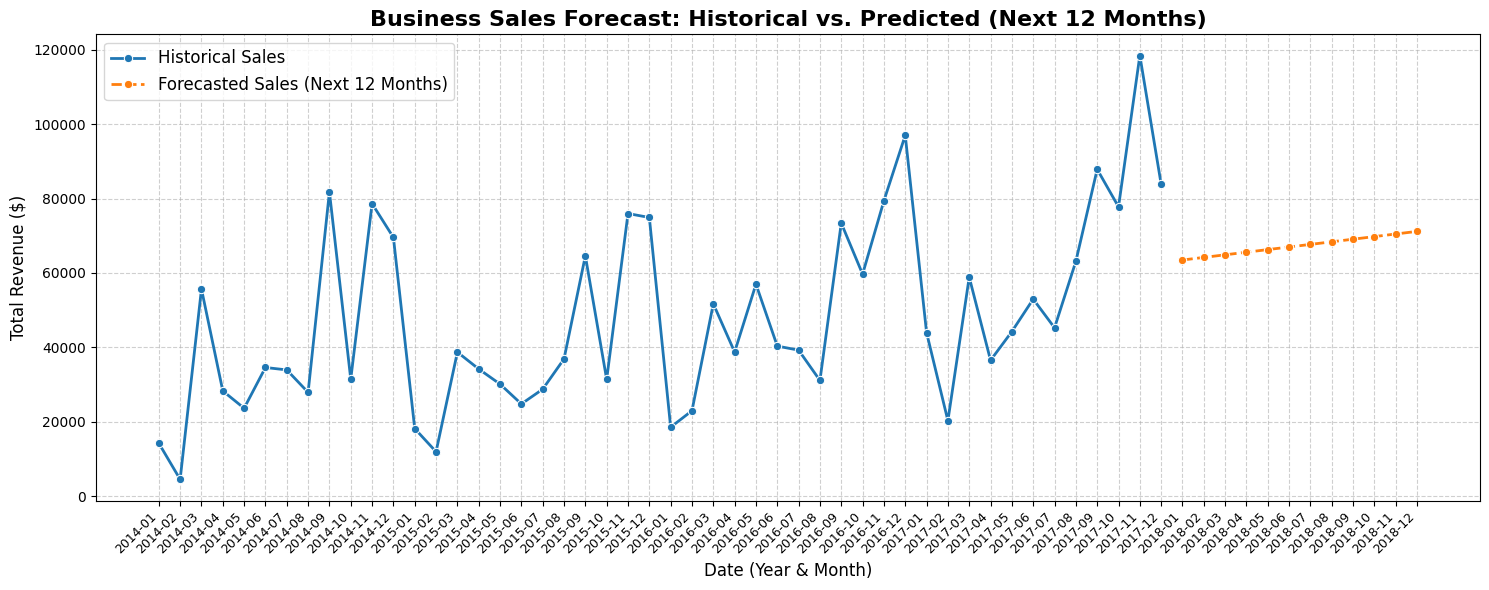

In [11]:
# 1. Ask the model to look 12 months into the future
future_time_indices = pd.DataFrame({'Time_Index': np.arange(len(monthly_sales) + 1, len(monthly_sales) + 13)})

# 2. Generate the predicted sales numbers for those next 12 months
future_predictions = model.predict(future_time_indices)

# 3. Create the calendar dates for the next 12 months so our chart makes sense
last_historical_date = pd.to_datetime(monthly_sales['Year-Month'].iloc[-1])
future_dates = [last_historical_date + pd.DateOffset(months=i) for i in range(1, 13)]
future_dates_str = [date.strftime('%Y-%m') for date in future_dates]

# 4. Build the Final Business Forecast Visualization
plt.figure(figsize=(15, 6))

# Plot the historical data we already know (Solid Blue Line)
sns.lineplot(x=monthly_sales['Year-Month'], y=monthly_sales['Sales'], label='Historical Sales', color='#1f77b4', marker='o', linewidth=2)

# Plot the FUTURE predicted data (Dashed Orange Line)
sns.lineplot(x=future_dates_str, y=future_predictions, label='Forecasted Sales (Next 12 Months)', color='#ff7f0e', marker='o', linestyle='--', linewidth=2)

# Make it look like a professional business dashboard
plt.title('Business Sales Forecast: Historical vs. Predicted (Next 12 Months)', fontsize=16, fontweight='bold')
plt.xlabel('Date (Year & Month)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

# Rotate the dates to prevent overlapping
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

# Display the final forecast chart!
plt.show()